# 5 · Where 500 Hz comes from — deriving a control rate from the plant

The board's control loop runs at **500 Hz**. Until this notebook, the only
justification for that number was that an interface document said so.

`docs/design-pi-image-stage0b.md` sources the rate to **ICD §11.2** and is
refreshingly blunt about what that means:

> **"500 Hz is an ICD number, not physics; the honest response to a platform
> that can't hold 2 ms is to say so and re-derive the rate."**

That would be a footnote, except that the Stage 0B go/no-go is written in terms
of the 2 ms period it implies. **AC-6** requires the command→actuation latency
to hold `p99.9 ≤ 1 ms` (half a period) and `max ≤ 2 ms` (one period). **AC-5**
budgets scheduler jitter at 25% of the same period. And the Raspberry Pi 5's
RP1 SPI controller has a reported tail spike of **1.5–2 ms**, which against a
2 ms period reads as *a whole missed cycle* and looks disqualifying.

At 5 ms the same spike would be 40% of a cycle and the same hardware would look
fine. So a pre-registered architecture decision was about to be settled by a
threshold nobody had derived. This notebook derives it.

**The short version.** The rate is not the interesting quantity. *Latency* is,
and the loop tolerates about **65 ms** of it. The sample rate spends exactly
half a period of that budget — **1 ms at 500 Hz**. 500 Hz stands, and now it
stands on something.

---

**Figure provenance.** Every figure below is either computed from the compiled
plant model or is a **Sim Replay** — MuJoCo, seeded and deterministic, produced
by `scripts/analyse_loop_rate.py`. None of it is Footage, none is a Hardware
Replay, and nothing here has touched a physical board. Categories per the
[Shared Vocabulary](https://app.notion.com/p/3aa472a5fb6981ebaaa7cf2e996f1e8b).

In [1]:
import json, math, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "sim" / "out" / "experiments"
sys.path.insert(0, str(REPO))
if not (DATA / "loop-rate.json").exists():
    raise SystemExit("Run:  scripts/analyse_loop_rate.py")

P = json.loads((DATA / "loop-rate.json").read_text())
INK, AMBER, MINT, MUTED, RED = "#16232E", "#F2A24A", "#2AAE97", "#96A8B0", "#C2513B"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

from sim.scenarios.loop_rate import (Gains, delay_margin, linearise,
                                     loop_transfer, sampled_delay_budget)
from sim.scenarios.plant import build_model

RIDDEN = build_model(70.0, 0.75, 40.0, "figure")       # 70 kg rider proxy, 0.75 m up
DRIVERLESS = build_model(0.0, 0.0, 40.0, "figure")     # the bare board
rp, dp = linearise(RIDDEN), linearise(DRIVERLESS)
GR = Gains(200.0, 30.0, 0.05, 0.02, com_above_axle=True)   # ridden cascade
GD = Gains(80.0, 11.0)                                     # driverless inner loop
print(f"strike angle {P['strike_angle_deg']}deg   sweep physics dt {P['sweep_physics_dt_ms']} ms")

strike angle 18.57deg   sweep physics dt 0.5 ms


---
## 1 · What kind of plant is this, really?

The issue that asked for this work came with a first estimate, explicitly
flagged as a prompt rather than a result:

> Point-mass inertia about the axle ≈ 33.1 kg·m²; unstable pole ≈ **3.94 rad/s**;
> error doubles in ~180 ms.

That treats the board as a lump of 82.5 kg at the centre-of-mass height,
swinging on a **pinned** axle. Two things are wrong with it, and they push in
opposite directions.

**The inertia is bigger than a point mass.** The rider proxy is a distributed
body, not a point: it carries 10.5 kg·m² about its own centre before the
parallel-axis term. Summed properly about the axle, `J = 50.28 kg·m²` against
the point-mass 33.1. On its own that would make the plant *slower*.

**The axle is not pinned.** This is a wheeled inverted pendulum. When the body
falls, the axle is free to accelerate out from under it, and that removes real
inertia from the pitch mode. Writing the Lagrangian in $(x, \theta)$ — axle
position along the direction of travel, and body pitch, nose-up positive per
ICD §10.1 — and linearising about upright:

$$
\begin{aligned}
M_t\,\ddot{x} - m l\,\ddot{\theta} &= \tfrac{1}{r}\,u \\
J\,\ddot{\theta} - m l\,\ddot{x} - m g l\,\theta &= u
\end{aligned}
\qquad
\begin{aligned}
M_t &= m + m_w + I_w/r^2 \\
u &= \tau - b\left(\dot{x}/r + \dot{\theta}\right)
\end{aligned}
$$

Eliminating $\ddot{x}$ gives a single second-order equation for the pitch:

$$
\underbrace{\left(J - \frac{(ml)^2}{M_t}\right)}_{J_{\text{eff}}}\ddot{\theta}
\;-\; mgl\,\theta \;=\;
\underbrace{\left(\frac{ml}{M_t r} + 1\right)}_{\text{torque leverage}}\tau
$$

$(ml)^2/M_t$ is 32.0 kg·m² of the 50.28 — **the free axle deletes 64% of the
pitch inertia.** The unstable pole is $\sqrt{mgl/J_{\text{eff}}}$, and it comes
out *faster* than either approximation.

In [2]:
s = rp.summary()
for k in ("m_body_kg", "com_above_axle_mm", "inertia_about_axle_kg_m2",
          "translating_mass_kg", "effective_pitch_inertia_kg_m2",
          "torque_leverage_per_n_m", "mgl_n_m_per_rad"):
    print(f"  {k:34s} {s[k]}")
print()
print(f"  point mass on a pinned axle    {s['point_mass_pole_rad_s']:.3f} rad/s   "
      f"(the figure this work was filed with)")
print(f"  real inertia, pinned axle      {s['fixed_pivot_pole_rad_s']:.3f} rad/s")
print(f"  THIS VEHICLE                   {s['unstable_pole_rad_s']:.3f} rad/s "
      f"= {s['unstable_pole_hz']:.3f} Hz")
print(f"  error doubles in               {s['doubling_time_ms']:.0f} ms "
      f"(the prompt said ~180 ms)")

  m_body_kg                          78.0
  com_above_axle_mm                  670.0
  inertia_about_axle_kg_m2           50.2822
  translating_mass_kg                85.3144
  effective_pitch_inertia_kg_m2      18.26994
  torque_leverage_per_n_m            5.21291
  mgl_n_m_per_rad                    512.671

  point mass on a pinned axle    3.935 rad/s   (the figure this work was filed with)
  real inertia, pinned axle      3.193 rad/s
  THIS VEHICLE                   5.239 rad/s = 0.834 Hz
  error doubles in               132 ms (the prompt said ~180 ms)


The board diverges **33% faster** than the point-mass estimate and **64% faster**
than a pinned pivot with the true inertia. 3.94 rad/s was not a bad guess — it
was two errors of opposite sign that did not quite cancel.

For the record, the driverless board — no rider, battery and hub motor putting
the centre of mass 19 mm *below* the axle — is not an inverted pendulum at all.
Gravity restores it. That is the plant the impulse gate and the Stage 0 bench
actually run, and it matters below, because it turns out to be the one with the
*tighter* delay budget.

### Validating the linearisation against the model it claims to describe

An algebra derivation is a hypothesis. Every constant above is read out of the
**compiled** MuJoCo model rather than retyped, so the only thing left to check
is whether the equations are right. Two ways: release the board from 0.5° and
watch it fall, and hit it with a constant torque from rest.

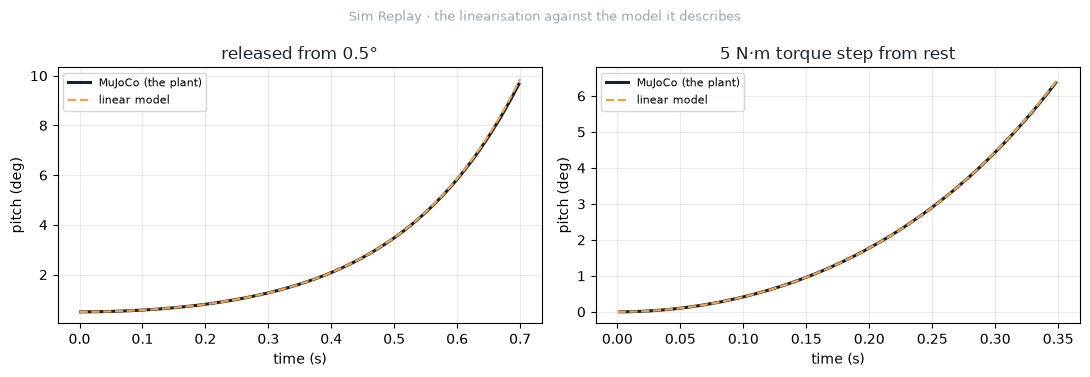

In [3]:
import mujoco
from sim.scenarios.impulse_response import frame_pitch_rad

def mj_run(model, theta0=0.0, tau=0.0, seconds=0.7):
    d = mujoco.MjData(model)
    if theta0: d.qpos[3:7] = [math.cos(theta0/2), 0.0, math.sin(theta0/2), 0.0]
    mujoco.mj_forward(model, d)
    t, th = [], []
    for _ in range(int(seconds / model.opt.timestep)):
        d.ctrl[0] = tau
        mujoco.mj_step(model, d)
        t.append(float(d.time)); th.append(frame_pitch_rad(model, d))
    return np.array(t), np.degrees(th)

def lin_run(plant, theta0=0.0, tau=0.0, seconds=0.7, dt=2e-4):
    x = np.array([0.0, theta0, 0.0, 0.0]); t, th = [], []
    for k in range(int(seconds/dt)):
        x = x + dt * (plant.A @ x + (plant.B * tau).ravel())
        t.append((k+1)*dt); th.append(x[1])
    return np.array(t), np.degrees(th)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
th0 = math.radians(0.5)
for a, (kw, title) in zip(ax, ((dict(theta0=th0), "released from 0.5°"),
                               (dict(tau=5.0, seconds=0.35), "5 N·m torque step from rest"))):
    tm, thm = mj_run(RIDDEN, **kw); tl, thl = lin_run(rp, **kw)
    a.plot(tm, thm, color=INK, lw=2.2, label="MuJoCo (the plant)")
    a.plot(tl, thl, color=AMBER, lw=1.6, ls="--", label="linear model")
    a.set_title(title, color=INK); a.set_xlabel("time (s)"); a.set_ylabel("pitch (deg)")
    a.legend(fontsize=8)
fig.suptitle("Sim Replay · the linearisation against the model it describes", color=MUTED, fontsize=9)
fig.tight_layout(); plt.show()

### The debugging story: a sign that cost a factor of 1.62

The first version of that right-hand plot did not overlay. MuJoCo pitched
**1.62×** further than the linear model for the same torque, at every instant,
which is the signature of a gain error rather than a dynamics error.

The cause was the sign of the hinge reaction. Driving the wheel forward does
two things to the body:

1. it accelerates the **axle** forward out from under the centre of mass, which
   tips the body back — nose up. Worth $ml/(M_t r) = 4.21$;
2. it torques the body **directly** through the hinge, by Newton's third law.
   Worth 1.0.

I had written those as opposing, giving a leverage of $4.21 - 1 = 3.21$. They
**add**: $4.21 + 1 = 5.21$. And $5.21/3.21 = 1.62$, exactly the discrepancy.

Physically it is obvious once seen — to catch a nose-down lean you drive
forward, and *both* effects pitch you back — but it is not obvious on paper,
because the sign depends on the hinge's coordinate convention, which lives in
the MJCF (`axis="0 -1 0"`) rather than in the algebra. The fix came from the
model disagreeing, not from re-reading the derivation.
`tests/test_loop_rate.py::test_the_linear_model_reproduces_a_torque_step` pins
the overlay so it cannot silently invert again.

---
## 2 · The number that actually matters is a delay budget

Here is the substitution the whole question turns on.

**AC-6 does not measure a sample rate. It measures a latency.** Those are
different quantities, and they enter the stability problem in completely
different ways:

- **Latency** is a pure delay, $e^{-sT}$. It is all-pass: it changes no
  amplitude anywhere, and it subtracts $\omega T$ of phase at every frequency.
  So it cannot move the gain crossover, only the phase margin *at* it.
- **A sample rate** enters as a zero-order hold, which to first order is worth
  $T_s/2$ of exactly that same pure delay, plus a small amplitude effect well
  above crossover.

So the rate's whole contribution to the stability problem is half a period, and
the honest question is: **how much total loop delay does this plant tolerate?**

Because the delay is all-pass, the answer is one division:

$$
T_{\text{margin}} \;=\; \frac{\text{phase margin (rad)}}{\omega_{\text{gc}}}
$$

Breaking the loop at the plant input — the motor — because that is where every
delay physically sits: transport to the drive, the drive's own current loop,
and the scheduler's lateness are all in series at that one point.

ridden cascade         crossover   3.38 rad/s   phase margin  13.8 deg   DELAY MARGIN   71.4 ms


driverless inner loop  crossover  18.59 rad/s   phase margin  69.9 deg   DELAY MARGIN   65.6 ms


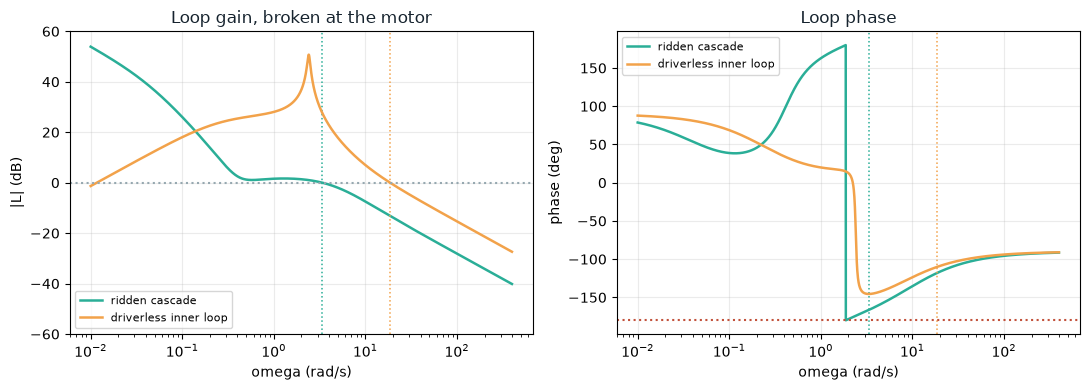

  driverless: delay leaving   45 deg of phase margin:   23.4 ms


  driverless: delay leaving   30 deg of phase margin:   37.4 ms


  driverless: delay leaving   10 deg of phase margin:   56.2 ms


In [4]:
w = np.logspace(-2, 2.6, 4000)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for plant, gains, name, colour in ((rp, GR, "ridden cascade", MINT),
                                   (dp, GD, "driverless inner loop", AMBER)):
    L = loop_transfer(plant, gains, w)
    m = delay_margin(plant, gains)
    ax[0].semilogx(w, 20*np.log10(np.abs(L)), color=colour, lw=1.8, label=name)
    ax[1].semilogx(w, np.degrees(np.angle(L)), color=colour, lw=1.8, label=name)
    for a in ax: a.axvline(m.crossover_rad_s, color=colour, ls=":", lw=1.1)
    print(f"{name:22s} crossover {m.crossover_rad_s:6.2f} rad/s   "
          f"phase margin {m.phase_margin_deg:5.1f} deg   "
          f"DELAY MARGIN {m.delay_margin_s*1e3:6.1f} ms")
ax[0].axhline(0, color=MUTED, ls=":"); ax[1].axhline(-180, color=RED, ls=":")
ax[0].set_ylabel("|L| (dB)"); ax[1].set_ylabel("phase (deg)"); ax[0].set_ylim(-60, 60)
for a in ax: a.set_xlabel("omega (rad/s)"); a.legend(fontsize=8)
ax[0].set_title("Loop gain, broken at the motor", color=INK)
ax[1].set_title("Loop phase", color=INK)
fig.tight_layout(); plt.show()

for tgt in (45.0, 30.0, 10.0):
    d = delay_margin(dp, GD).delay_at_phase_margin_s(tgt)*1e3
    print(f"  driverless: delay leaving {tgt:4.0f} deg of phase margin: {d:6.1f} ms")

**The budget is 65 ms**, set by the driverless inner loop — which is the tighter
of the two despite being the *stable* plant, because it crosses over five times
higher (18.6 rad/s against 3.4) and delay costs phase in proportion to
frequency. The ridden cascade tolerates 71 ms.

Quoting a budget at zero phase margin is quoting the cliff edge, so at a stated
**30° of phase margin** the driverless loop still allows **37 ms**.

Two honest caveats before that number is used for anything:

- **The ridden cascade's own phase margin is 13.8°**, which is thin. It is thin
  because of how the outer velocity loop is tuned, not because of any delay, and
  it is why a 30° figure cannot be quoted for that configuration at *any* delay.
  That is a tuning observation for a separate increment. Retuning it inside a
  notebook about sample rate would be scope creep dressed up as a fix.
- **This is a small-signal result.** It knows nothing about the 40 A current
  limit or the nose strike at 18.6°. Section 4 is where those bite, and they
  bite well before the phase does.

### Two independent derivations, and they have to agree

A phase-margin argument leans on the $T_s/2$ approximation for the hold. So
here is the same question asked without it: discretise the plant exactly across
each sample with the input piecewise-constant, add an input delay split exactly
between the two commands that straddle it, close the loop, and ask when an
eigenvalue leaves the unit disc. No approximation of the sampling anywhere.

If the $T_s/2$ story is right, `(sampled budget) + Ts/2` must be a constant.

In [5]:
rows = P["analytic"]["ridden"]["sampled"]
print(" rate Hz   Ts/2 (ms)   sampled budget (ms)   sum (ms)")
for r in rows:
    print(f" {r['rate_hz']:7g}   {r['zoh_half_period_ms']:9.2f}   "
          f"{r['added_delay_budget_ms']:19.2f}   {r['total_equivalent_ms']:8.2f}")
tot = np.array([r["total_equivalent_ms"] for r in rows])
print(f"\n spread across 31.25 -> 1000 Hz: {(tot.max()-tot.min())/tot.mean()*100:.2f}%")
print(f" continuous phase-margin answer: "
      f"{delay_margin(rp, GR).delay_margin_s*1e3 - 1.0:.2f} ms (less the 1 ms current loop)")

 rate Hz   Ts/2 (ms)   sampled budget (ms)   sum (ms)
   31.25       16.00                 54.91      70.91
    62.5        8.00                 62.75      70.75
     125        4.00                 66.54      70.54
     250        2.00                 68.47      70.47
     500        1.00                 69.44      70.44
    1000        0.50                 69.92      70.42

 spread across 31.25 -> 1000 Hz: 0.69%


 continuous phase-margin answer: 70.40 ms (less the 1 ms current loop)


Constant to 0.7% over five octaves. The rate enters the answer through exactly
one term, and it is $T_s/2$.

**Which settles the framing question.** Doubling 500 Hz to 1000 Hz returns
0.5 ms of a 70 ms budget — 0.7%. Halving it to 250 Hz costs 1 ms — 1.4%. Neither
is a decision worth making on stability grounds.

And it puts AC-6 in proportion:

| quantity | value | as a fraction of the 65 ms budget |
|---|---|---|
| AC-6 `p99.9` threshold | 1 ms | 1.5% |
| AC-6 `max` threshold | 2 ms | 3.0% |
| the Pi 5 RP1 SPI tail spike | 1.5–2 ms | 2.3–3.0% |
| what 500 Hz itself costs | 1 ms | 1.5% |

**The SPI spike is not disqualifying on control-law grounds.** It reads that
way only because AC-6 states its threshold as a fraction of the *period*, and
the period is not what the transport is competing with.

---
## 3 · What the linear model cannot say

Everything above is a small-signal argument about an unbounded actuator. The
real loop has:

- a **40 A** current envelope, which a large disturbance reaches;
- a **nose strike at 18.6°**, past which "pitch" stops being a linear coordinate
  and becomes a collision;
- an **estimator** in the loop — a complementary filter whose accelerometer
  branch is corrupted by the board's own longitudinal acceleration (that is
  notebook 4's subject, and it is a feedback path, not a lag);
- **quantised, held wheel-rate telemetry** at the drive's own 500 Hz status rate;
- a **current loop** that does not deliver a step.

So: the same question, in the simulator, over a grid of rate × delay. The
disturbance is the standard 20 N·s impulse the CI gate already uses, and the
gains, plant and imperfection profile are the ones the merge gates run.

Two methodological notes, both learned by getting them wrong first:

- **The physics runs 4× finer than the model's own 2 ms timestep**, because the
  model's timestep *is* 500 Hz and a rate sweep that cannot represent a rate
  above the one under test is not a sweep. That is a fidelity change, so it is
  checked rather than assumed.
- **Each grid point is run at three sub-period offsets and reported by its
  worst outcome.** At low rates the peak pitch depends strongly on where the
  kick lands relative to the next control cycle — a first pass had 15 Hz
  looking *better* than 50 Hz, which is an artefact of phase, not a property of
  rate.

In [6]:
c = P["physics_timestep_control"]
peaks = np.array([r["peak_abs_pitch_deg"] for r in c])
for r in c:
    print(f"  physics dt {r['physics_dt_ms']:5.2f} ms -> peak |pitch| "
          f"{r['peak_abs_pitch_deg']:.4f} deg,  travel {r['travel_m']:+.4f} m")
print(f"\n  spread {(peaks.max()-peaks.min())/peaks.mean()*100:.1f}% -- smaller than any "
      f"effect reported below")

  physics dt  2.00 ms -> peak |pitch| 7.6304 deg,  travel -0.0458 m
  physics dt  1.00 ms -> peak |pitch| 7.5996 deg,  travel -0.0477 m
  physics dt  0.50 ms -> peak |pitch| 7.6957 deg,  travel -0.0506 m
  physics dt  0.25 ms -> peak |pitch| 7.5331 deg,  travel -0.0485 m

  spread 2.1% -- smaller than any effect reported below


peak |pitch| in degrees, ridden cascade;  * = the nose hit the ground
  rate |        0        4        8       16       24       32       40       48   ms of transport delay
 31.25 |    8.74     9.73    10.83    13.40    35.93*   12.85    31.63*   99.90*
  62.5 |    7.72     8.55     9.44     9.31    11.57    11.60    99.90*   35.06*
   125 |    8.03     8.81     8.78     9.67    10.74    12.04    21.75*   22.32*
   250 |    7.78     8.14     8.53     9.40    10.45    11.72    19.54*   46.21*
   500 |    7.57     7.92     8.30     9.16    10.19    11.42    13.01    99.90*
  1000 |    7.56     7.91     8.28     9.14    10.17    11.40    13.03    99.90*


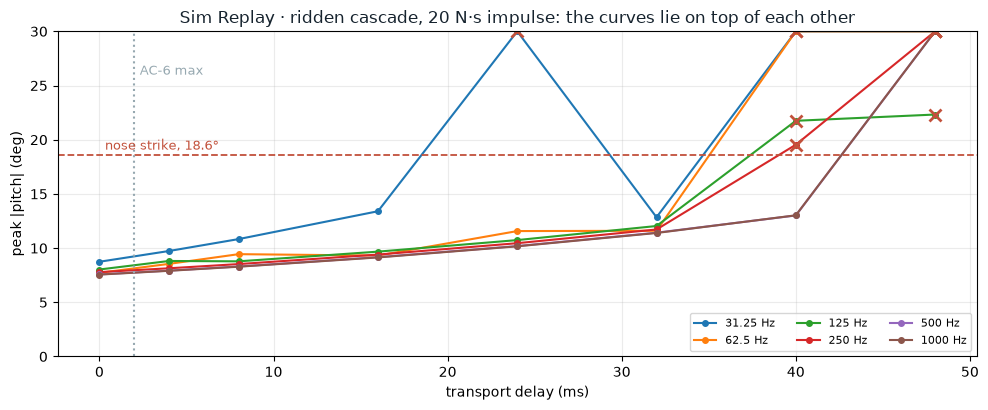

In [7]:
rows = P["sweep"]["ridden_rate_delay"]
rates = sorted({r["rate_hz"] for r in rows})
delays = sorted({r["delay_ms"] for r in rows})
print("peak |pitch| in degrees, ridden cascade;  * = the nose hit the ground")
print("  rate |" + "".join(f"{d:>9.0f}" for d in delays) + "   ms of transport delay")
for rt in rates:
    cells = ""
    for d in delays:
        r = next(x for x in rows if x["rate_hz"] == rt and x["delay_ms"] == d)
        cells += f"{min(r['peak_abs_pitch_deg'], 99.9):8.2f}{'*' if r['struck'] else ' '}"
    print(f"{rt:6g} |{cells}")

fig, ax = plt.subplots(figsize=(10, 4.2))
for rt in rates:
    sel = sorted([r for r in rows if r["rate_hz"] == rt], key=lambda r: r["delay_ms"])
    ax.plot([r["delay_ms"] for r in sel],
            [min(r["peak_abs_pitch_deg"], 30) for r in sel], "o-", lw=1.5, ms=4,
            label=f"{rt:g} Hz")
    for r in sel:
        if r["struck"]:
            ax.plot(r["delay_ms"], min(r["peak_abs_pitch_deg"], 30), "x", color=RED, ms=9, mew=2)
ax.axhline(P["strike_angle_deg"], ls="--", color=RED, lw=1.3)
ax.annotate("nose strike, 18.6°", (0, P["strike_angle_deg"]), color=RED, fontsize=9,
            textcoords="offset points", xytext=(4, 4))
ax.axvline(2.0, ls=":", color=MUTED)
ax.annotate("AC-6 max", (2.0, 26), color=MUTED, fontsize=9,
            textcoords="offset points", xytext=(4, 0))
ax.set_xlabel("transport delay (ms)"); ax.set_ylabel("peak |pitch| (deg)"); ax.set_ylim(0, 30)
ax.set_title("Sim Replay · ridden cascade, 20 N·s impulse: the curves lie on top of each other",
             color=INK)
ax.legend(fontsize=8, ncol=3); fig.tight_layout(); plt.show()

**For the first 32 ms — the entire region that matters — the six rate curves
lie on top of one another.** From 62.5 Hz to 1000 Hz, a sixteen-fold range, the
peak excursion at any delay up to 32 ms differs by at most 1.4°, and every rate
survives. AC-6's ceiling is 2 ms. That is a **twenty-fold margin, measured**.

Rate only separates at the very edge, at 40 ms — and *how* it separates is the
best confirmation in this notebook that the $T_s/2$ story is right. Add half a
period to the transport delay and the boundary should stop depending on rate at
all:

In [8]:
print(" rate Hz | transport | + Ts/2 | = effective delay | struck")
for rt in rates:
    for d in (32.0, 40.0, 48.0):
        r = next(x for x in rows if x["rate_hz"] == rt and x["delay_ms"] == d)
        half = 500.0/rt
        print(f" {rt:7g} | {d:8.0f}  | {half:5.1f}  | {d+half:16.1f}  | "
              f"{'STRUCK' if r['struck'] else 'ok'}")
    print(" " + "-"*62)

 rate Hz | transport | + Ts/2 | = effective delay | struck
   31.25 |       32  |  16.0  |             48.0  | ok
   31.25 |       40  |  16.0  |             56.0  | STRUCK
   31.25 |       48  |  16.0  |             64.0  | STRUCK
 --------------------------------------------------------------
    62.5 |       32  |   8.0  |             40.0  | ok
    62.5 |       40  |   8.0  |             48.0  | STRUCK
    62.5 |       48  |   8.0  |             56.0  | STRUCK
 --------------------------------------------------------------
     125 |       32  |   4.0  |             36.0  | ok
     125 |       40  |   4.0  |             44.0  | STRUCK
     125 |       48  |   4.0  |             52.0  | STRUCK
 --------------------------------------------------------------
     250 |       32  |   2.0  |             34.0  | ok
     250 |       40  |   2.0  |             42.0  | STRUCK
     250 |       48  |   2.0  |             50.0  | STRUCK
 --------------------------------------------------------

Every effective delay of 42 ms or more strikes; 40.5 and 41 ms survive. Six
rates, one boundary at **≈41 ms of total equivalent delay**, recovered from a
nonlinear simulation with a saturating actuator and a collision — by a
correction derived from a linear frequency-domain argument. The rate is not a
separate variable. It is $T_s/2$ of the delay, and nothing else.

**One honest wrinkle.** At 31.25 Hz the outcomes are not monotonic: it strikes
at 24 ms and survives at 32 ms. That is the same non-monotonicity the
disturbance-envelope work already measured near this strike angle — the peak
sits within a degree or so of 18.6° across a wide band, so which side of the
line a given run lands on is a knife edge that moves with any small change.
It is reported rather than smoothed, and it is the reason the boundary above is
quoted as a bracket rather than bisected to a single number.

### Where it goes over, and why — it is current, not phase

The simulated boundary (~40 ms) is tighter than the linear delay margin
(~71 ms), and the reason is worth more than the number.

In [9]:
sel = sorted([r for r in rows if r["rate_hz"] == 500.0], key=lambda r: r["delay_ms"])
print(" delay ms | saturated cycles | control effort (A·s) | peak |pitch| | struck")
for r in sel:
    print(f" {r['delay_ms']:8g} | {r['saturated_cycles']:16d} | "
          f"{r['control_effort_a_s']:20.1f} | {r['peak_abs_pitch_deg']:11.2f} | {r['struck']}")

 delay ms | saturated cycles | control effort (A·s) | peak |pitch| | struck
        0 |                0 |                 49.4 |        7.57 | False
        4 |                0 |                 52.3 |        7.92 | False
        8 |                0 |                 55.6 |        8.30 | False
       16 |                0 |                 63.6 |        9.16 | False
       24 |                0 |                 74.1 |       10.19 | False
       32 |                0 |                 88.5 |       11.42 | False
       40 |              218 |                110.9 |       13.01 | False
       48 |             1595 |                154.2 |      179.98 | True


Up to 32 ms the envelope never clamps: the loop is losing margin but it always
has the authority to ask for what it needs. At 40 ms it saturates on 218 cycles
and survives; at 48 ms it saturates on most of the run and goes over.

**The board runs out of current before it runs out of phase.** The linear
model, which has no current limit, cannot see that and is optimistic by
roughly 1.8× on the ridden vehicle. On the *driverless* board, whose
disturbance response peaks under 5° and never approaches the envelope, the two
agree closely — the simulated boundary lands between 64 and 80 ms against a
65.6 ms prediction, which is about as good as this kind of agreement gets.

That is a useful thing to know independently of rate: **the way to buy delay
tolerance on this vehicle is amps, not hertz.**

---
## 4 · Jitter buys nothing back either

AC-5 budgets jitter as *25% of the period*, which is a rate-relative statement
of the same kind as AC-6's. So it deserves the same test.

Jitter is modelled one-sided and late — a cycle can miss its deadline, it
cannot run before its own wake-up. A symmetric model would cancel to zero mean
and make jitter look free.

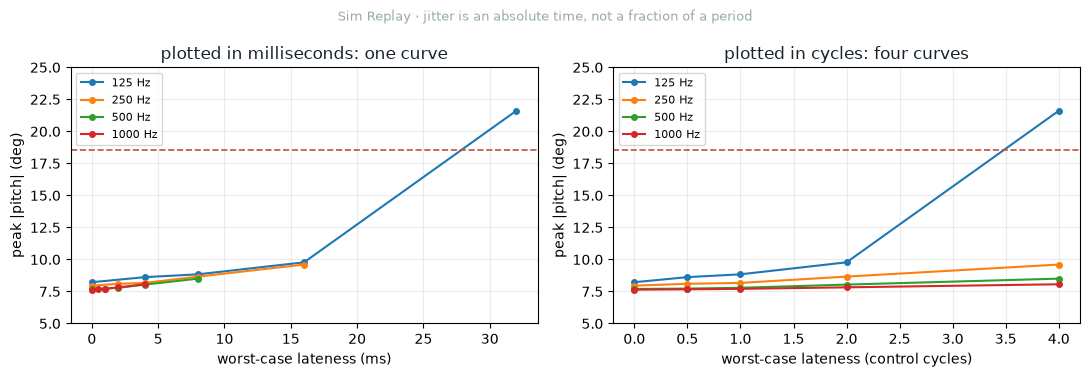

In [10]:
jr = P["sweep"]["ridden_jitter"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for rt in sorted({r["rate_hz"] for r in jr}):
    sel = sorted([r for r in jr if r["rate_hz"] == rt], key=lambda r: r["jitter_ms"])
    ax[0].plot([r["jitter_ms"] for r in sel],
               [min(r["peak_abs_pitch_deg"], 25) for r in sel], "o-", lw=1.5, ms=4,
               label=f"{rt:g} Hz")
    ax[1].plot([r["jitter_ms"]*r["rate_hz"]/1000.0 for r in sel],
               [min(r["peak_abs_pitch_deg"], 25) for r in sel], "o-", lw=1.5, ms=4,
               label=f"{rt:g} Hz")
ax[0].set_xlabel("worst-case lateness (ms)"); ax[1].set_xlabel("worst-case lateness (control cycles)")
for a in ax:
    a.axhline(P["strike_angle_deg"], ls="--", color=RED, lw=1.2)
    a.set_ylabel("peak |pitch| (deg)"); a.legend(fontsize=8); a.set_ylim(5, 25)
ax[0].set_title("plotted in milliseconds: one curve", color=INK)
ax[1].set_title("plotted in cycles: four curves", color=INK)
fig.suptitle("Sim Replay · jitter is an absolute time, not a fraction of a period", color=MUTED, fontsize=9)
fig.tight_layout(); plt.show()

Plotted against absolute lateness the four rates collapse onto one curve;
plotted against *cycles* of lateness they fan out. Jitter is a delay, and
delays are measured in seconds.

**So AC-5's "25% of the period" is the wrong shape for the same reason as
AC-6's "one period".** At 500 Hz it happens to mean 500 µs, which is a
comfortable 0.8% of the budget — the number is fine, the *derivation* was
missing, and the form it is written in would give the wrong answer at any other
rate.

---
## 5 · The assumption that could invalidate all of this: sensor noise

A rate sweep is only as good as its noise model, because noise is the thing
that ought to punish a *high* rate. Low rates lose phase margin; high rates are
supposed to amplify high-frequency noise through derivative action. A sweep
against clean sensing is optimistic in both directions.

**So here is exactly what is modelled**, from ICD §12's placeholder profile —
every value a datasheet-derived placeholder awaiting Stage-0 bench measurement,
not a fitted number:

In [11]:
prof = P["imperfection_profile"]
for k in ("gyro_noise_rad_s", "gyro_bias_rad_s", "accel_noise_m_s2",
          "wheel_rate_quantum_rad_s", "wheel_rate_update_hz",
          "actuation_delay_s", "current_loop_tau_s", "max_current_a"):
    print(f"  {k:26s} {prof[k]}")
print()
kd = GR.kd_a_per_rad_s
print(f"  gyro noise on the D term:   {kd} A/(rad/s) x {prof['gyro_noise_rad_s']} rad/s "
      f"= {kd*prof['gyro_noise_rad_s']:.3f} A  "
      f"({kd*prof['gyro_noise_rad_s']/prof['max_current_a']*100:.2f}% of the 40 A cap)")
print(f"  accel noise as tilt:        {prof['accel_noise_m_s2']}/9.81 = "
      f"{math.degrees(prof['accel_noise_m_s2']/9.81):.3f} deg, then low-passed by the "
      f"1 s complementary filter")

  gyro_noise_rad_s           0.004
  gyro_bias_rad_s            0.002
  accel_noise_m_s2           0.02
  wheel_rate_quantum_rad_s   0.00698
  wheel_rate_update_hz       500.0
  actuation_delay_s          0.001
  current_loop_tau_s         0.001
  max_current_a              40.0

  gyro noise on the D term:   30.0 A/(rad/s) x 0.004 rad/s = 0.120 A  (0.30% of the 40 A cap)
  accel noise as tilt:        0.02/9.81 = 0.117 deg, then low-passed by the 1 s complementary filter


**Note what the D term consumes: a *measured* gyro rate, not a difference of
two pitch samples.** That is the whole reason the classic "high rate amplifies
derivative noise" objection does not apply to this loop. A backward difference
would scale noise as $1/T_s$ and genuinely punish a fast loop; reading a rate
gyro does not. Its noise contribution is 0.12 A out of 40 A at any rate.

That is an argument, though, and the point of having a simulator is not to
argue. Here is the sensitivity: scale both white-noise terms together and see
where the answer moves.

In [12]:
nr = P["sweep"]["ridden_noise"]
print(" rate |" + "".join(f"{s:>10s}" for s in ("x1", "x3", "x10", "x30", "x100"))
      + "    peak |pitch| deg, * = strike")
for rt in sorted({r["rate_hz"] for r in nr}):
    sel = sorted([r for r in nr if r["rate_hz"] == rt], key=lambda r: r["noise_scale"])
    print(f"{rt:5g} |" + "".join(
        f"{min(r['peak_abs_pitch_deg'],99.9):9.2f}{'*' if r['struck'] else ' '}" for r in sel))
print("\nattitude-estimate RMS error (deg):")
for rt in sorted({r["rate_hz"] for r in nr}):
    sel = sorted([r for r in nr if r["rate_hz"] == rt], key=lambda r: r["noise_scale"])
    print(f"{rt:5g} |" + "".join(f"{r['pitch_est_rms_deg']:10.2f}" for r in sel))

 rate |        x1        x3       x10       x30      x100    peak |pitch| deg, * = strike
  125 |     8.22      9.07     12.10     27.59*    19.10*
  250 |     7.95      8.20      9.31     14.23     21.30*
  500 |     7.70      7.76      8.20     10.93     30.69*
 1000 |     7.64      7.71      8.06     10.12     99.90*

attitude-estimate RMS error (deg):
  125 |      0.41      0.52      1.17     10.60     10.11
  250 |      0.38      0.46      1.04      2.98     19.28
  500 |      0.37      0.46      1.04      2.98     10.62
 1000 |      0.36      0.45      1.00      2.84    152.08


Three things fall out, and one of them is a warning.

1. **At the modelled noise level the answer is not noise-limited anywhere.**
   Between 125 Hz and 1000 Hz the peak excursion varies by 0.6°.
2. **It takes 10–30× the modelled noise before rate matters at all**, and when
   it does, it is the *slow* loop that fails first: 125 Hz strikes at ×30 while
   500 Hz and 1000 Hz are still upright. Higher rate is weakly *better* under
   white noise, exactly as the "measured rate, not a difference" argument
   predicts. There is no high-rate penalty in this model.
3. **And that is precisely the problem with claiming there is no high-rate
   penalty at all**, because the only noise in this model is white.

The mechanisms that would actually punish a fast loop are the ones with
structure: **gyro bias instability** and **angle random walk**, which are
coloured; **motor vibration coupling** into the IMU, which is narrowband and
lands squarely in the band a balance loop cares about; and **aliasing** of
anything above the sample rate, which by construction cannot be represented by
a sweep whose IMU is sampled at the control rate. None of those are in the
model. A white-noise sweep cannot see any of them.

**So the sensitivity result is one-sided, and it is stated that way:** it is
evidence that the *low*-rate side of the answer is not noise-limited, and it is
not evidence that the high-rate side is safe. It does not change the
conclusion — 500 Hz is not at the high-rate extreme of anything, and the
mechanisms above would have to be enormous to close a 20× margin — but it is
the assumption a later fidelity improvement should come back and check.

---
## 6 · What this notebook is not good enough to answer

Stated explicitly, so a later fidelity improvement knows what it is for.

1. **IMU spectral content.** The model has white gyro and accelerometer noise
   and a constant bias. It has no bias instability, no angle random walk, and
   no vibration coupling from the motor. Those are the mechanisms that would
   create a high-rate penalty, and the sweep is blind to all of them. **This is
   the load-bearing gap.**
2. **IMU rate is welded to control rate.** The FFI carries one inertial sample
   per cycle, so lowering the control rate also lowers the sampling rate of the
   estimator. `control_core::Estimator::update` explicitly takes a *batch* of
   samples for this reason ("sub-sampling a ≥1 kHz IMU at a 500 Hz loop aliases
   the estimator's primary input"), and the sim cannot exercise that path. So
   the sweep conflates two rates that the hardware separates, and the low-rate
   results are pessimistic by an unknown amount.
3. **No tyre model, no compliance.** The wheel is a rigid cylinder on a rigid
   plane. A real tyre has sidewall compliance and a contact patch with finite
   stiffness, both of which add dynamics — and phase — inside the band this
   analysis is about.
4. **The rider is a rigid lump.** A real rider articulates at the ankles and
   knees and absorbs disturbance. The ballast does neither, which changes both
   the inertia and the excitation.
5. **`kt` is an unfitted placeholder.** 0.7 N·m/A is an order-of-magnitude
   guess. The delay budget scales with it: everything that sets the crossover
   frequency is proportional to loop gain, and loop gain is proportional to
   `kt`. A `kt` twice as large would roughly halve the delay budget. That single
   bench measurement is the highest-value thing that could sharpen this result.
6. **VESC cutback is only modelled as a speed-dependent layer.** Section 3
   showed the boundary is set by running out of current. A real drive derates
   for voltage sag and temperature too, and neither is modelled — so the
   current-limited boundary here is, if anything, optimistic.
7. **Nothing here has met hardware.** The delay budget is a property of a model
   whose plant constants are placeholders. It is a *design* budget, not a
   measurement.

---
## 7 · The verdict

**500 Hz stands.** Not because the ICD says so, and not because it is optimal —
it is comfortably over-specified — but because the derivation now exists and
the number is a good one:

- The plant's unstable pole is **5.24 rad/s** (0.83 Hz), doubling in **132 ms**.
  500 Hz is 600× that, which is generous by any classical rule and costs
  nothing.
- The loop's total delay budget is **≈65 ms** analytically at zero phase margin,
  **37 ms** at a stated 30°, and **≈40 ms** in simulation where the current
  envelope binds first.
- **The rate spends 1 ms of it.** Everything else in the budget — transport,
  actuation, the current loop, scheduler lateness — has ~40 ms to share.
- 500 Hz also happens to be the drive's own STATUS/command rate (ICD §11.2), so
  it is free: a faster control loop could not command a faster drive, and a
  slower one would throw away telemetry that is arriving anyway. **That is the
  real justification for the number, and it is an interface argument — it was
  right, it was just never checked against the plant.**

### What this means for Stage 0B's acceptance criteria

**No threshold needs to move**, and this notebook does not move any. `p99.9 ≤
1 ms` and `max ≤ 2 ms` are 1.5% and 3.0% of the budget: conservative by a factor
of 20–65, easily met, and now derived rather than inherited.

Two recommendations follow, and both are for the owners of those criteria
rather than for this notebook to enact:

1. **AC-5 and AC-6 should be restated against the delay budget, not the
   period.** The numbers can stay exactly as they are. The *form* is what is
   wrong: "half a period" and "25% of the period" would give the wrong answer
   at any other rate, and they are what made a 1.5–2 ms SPI spike look
   disqualifying.
2. **The 1.5–2 ms RP1 SPI tail spike is not disqualifying on control-law
   grounds.** It is 2.3–3.0% of the delay budget. Whether it disqualifies the
   transport for *other* reasons — determinism, what else is on that bus, what
   the spike implies about the rest of the driver — is a Stage 0B question and
   this notebook takes no view on it. It simply removes "the control loop
   cannot tolerate it" from the list of reasons.

### Reproducing this

```sh
.venv/bin/pip install -r requirements-sim.txt
cargo build --release -p control-ffi
.venv/bin/python scripts/analyse_loop_rate.py     # ~2 minutes, writes sim/out/experiments/
.venv/bin/jupyter lab notebooks/
```

Every run is deterministic and seeded; re-running reproduces every number above
bit-for-bit on the pinned MuJoCo. The analytic half is pinned by
`tests/test_loop_rate.py`, which runs in the merge gate.

**Read next:** notebook 1 for where the equations of motion come from,
notebook 2 for how the cascade is tuned, and notebook 4 for why the estimator
is a feedback path rather than a lag — which is the one thing in the loop that
this notebook's delay budget does *not* describe.